In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

import sys

sys.path.append('../src')

from Config.config import PATHS

import warnings
warnings.filterwarnings("ignore")

In [39]:
from Utils.interaction import Performer
from Utils.utils import GetMeasurements
from Classes.cognitive_model_agents import FocalRegionAgent

### Simulation with different number of schemata

In [40]:
free_parameters = {
    'inverse_temperature': 8,
    'learning_rate': 0.2,
    'bias': 1,
    'forget': 0.8,
    'len_history': 2,
    'delta': 0.4,
    'max_regions': 3,
}

simulation_parameters = {
    'num_rounds': 20,
    'num_episodes': 100,
    'verbose': False
}
df_list = []

list_fixed_parameters = [
    (2, 0.5),
    (3, 1/3), (3, 2/3),
    (4, 1/4), (4, 0.5), (4, 3/4),
    (5, 2/5), (5, 3/5), (5, 4/5),
    (6, 2/6), (6, 0.5), (6, 4/6),
    (8, 3/8), (8, 5/8), (8, 7/8),
]

In [41]:
for max_regions in tqdm([1, 3, 6], desc='max_regions'):
    for num_agents, threshold in tqdm(
        list_fixed_parameters,
        desc=f'regions={max_regions}',
        leave=False,
    ):
        fixed_parameters = {
            'num_agents': num_agents,
            'threshold': threshold,
        }
        model_class = FocalRegionAgent
        df = Performer.sim(
            agent_class=model_class,
            fixed_parameters=fixed_parameters,
            free_parameters=free_parameters,
            simulation_parameters=simulation_parameters,
        )
        # df['model'] = model_class.name()
        df['model'] = f"{max_regions}"
        df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
df['bounded_score'] = df['score'] / df['threshold']
df.head(2)

max_regions:   0%|          | 0/3 [00:00<?, ?it/s]

regions=1:   0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

,id_sim,round,attendance,id_player,decision,score,model,threshold,num_agents,bounded_score
0,7a79de8c-a0a8-11f1-90ac-beb3bfa57af2,0,"[0, 0]",0,0,0,1,0.5,2,0.0
1,7a79de8c-a0a8-11f1-90ac-beb3bfa57af2,0,"[0, 0]",1,0,0,1,0.5,2,0.0


<Axes: xlabel='round', ylabel='bounded_score'>

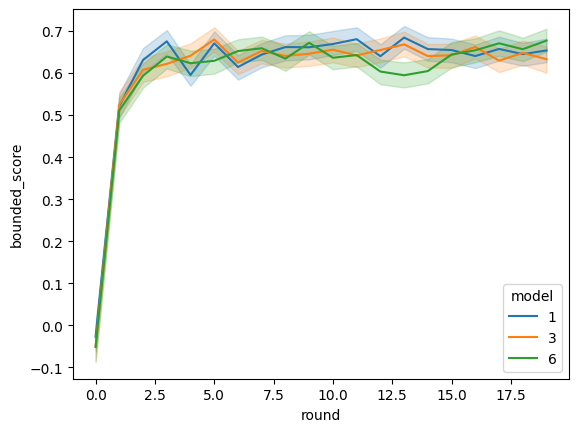

In [42]:
sns.lineplot(
    data=df, 
    x='round', 
    y='bounded_score', 
    hue='model'
)

In [46]:
gm = GetMeasurements(
    data=df, measures=['bounded_efficiency', 'gini_index']
)
data = gm.get_measurements()
data.head(2)

,model,threshold,num_agents,id_sim,bounded_efficiency,gini_index
0,1,0.25,4,7bf7d174-a0a8-11f1-90ac-beb3bfa57af2,0.65,0.018817
1,1,0.25,4,7bfb13f2-a0a8-11f1-90ac-beb3bfa57af2,0.80,0.015625


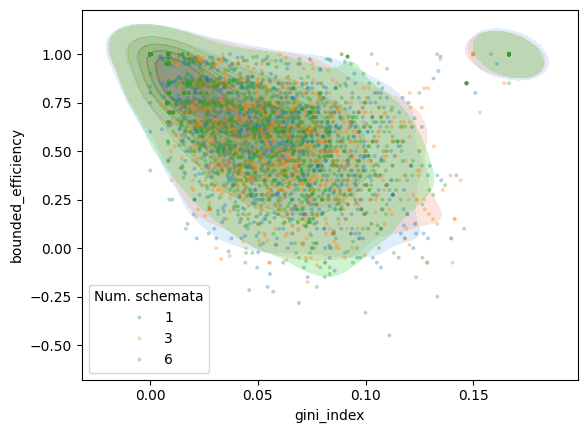

In [47]:
sns.kdeplot(
    data=data,
    x='gini_index',
    y='bounded_efficiency',
    hue='model',
    fill=True,
    alpha=0.3,
    levels=6,
    thresh=0.05,
    legend=False,
)
ax = sns.scatterplot(
    data=data,
    x='gini_index',
    y='bounded_efficiency',
    hue='model',
    s=8,
    alpha=0.35,
    edgecolor='none',
    linewidth=0,
)
ax.legend(title='Num. schemata')

### Fit to human data

In [45]:
from Classes.parameter_recovery import ParameterFit

In [ ]:
# Load data into a dataframe
all_data = True

file_name = 'multi-player.csv' # <= Data from all experiments combined
best_fits_file = PATHS['parameter_fit_results'] / Path('best_fit_all.json')
data_folder = PATHS['human_data']
file = data_folder / Path(file_name)
print(f'Loading data from {file}...')

data = pd.read_csv(file)
columns = ['threshold', 'num_players', 'group', 'round', 'player', 'score', 'decision']
drop_columns = [col for col in data.columns if col not in columns]
data.drop(columns=drop_columns, inplace=True)
print(f"Number of data points: {data.size}")

In [ ]:
hyperparameters = {
    'init_points':128,
    'n_iter':64
}

ParameterFit.run(
    data=data,
    model_list=[FocalRegionAgent],
    best_fit_path=PATHS['parameter_fit_results'] / 'best_fit_Bayesian.json',
    optimizer_type='bayesian',
    hyperparameters=hyperparameters,
    new_file=True
)